# ***Earth Foundation Models* (EFM): eficiência amostral (*Few-Shot Challenge*)**

Nos tutoriais anteriores, vimos como extrair representações vetoriais (*embeddings*) de imagens de satélite, baixar os próprios *embeddings* (*Google Satellite Embeddings*) e como trabalhar com modelos fundacionais em grande escala no mapeamento de uso e cobertura da terra (utilizando o tutorial do OlmoEarth).

Agora, podemos nos fazer a seguinte pergunta: **Por que não utilizar diretamente bandas espectrais no treinamento de modelos a partir do zero, que sejam altamente especializados na aplicação de interesse?**

A principal promessa dos EFMs é a **eficiência amostral** (*sample efficiency*). Em sensoriamento remoto, obter amostras rotuladas e de qualidade é um processo custoso, demorado e muitas vezes inviável. Um modelo fundacional pré-treinado em terabytes de dados globais já compreende estruturas contextuais da superfície terrestre, exigindo uma quantidade menor de rótulos/exemplos para aprender uma tarefa. Bem, ao menos é o que esses modelos almejam.

---

### **Experimento**
Neste notebook, testamos os limites de aprendizado com amostras escassas (**2, 5, 10 e 20 amostras por classe**) no *dataset* **EuroSAT** (10 classes de cobertura e uso da terra). Trata-se de um problema de *scene classification*, em que cada *patch* possui um rótulo.

Avaliamos o mesmo algoritmo de classificação supervisionada (Regressão Logística) em três abordagens, usando as mesmas amostras/imagens:

1. **Bandas espectrais (RGB):** utiliza apenas a média de reflectância das bandas visíveis B02 (Azul), B03 (Verde) e B04 (Vermelho) do Sentinel-2, o que origina um vetor com três dimensões espectrais;
2. **Bandas espectrais (RGB + NIR):** adiciona o infravermelho próximo (B08 - NIR) às bandas RGB, originando um vetor com quatro dimensões espectrais;
3. ***Earth foundation model* (DOFA):** as mesmas quatro bandas da abordagem 2, processadas pelo DOFA que gera um vetor contextual (*embeddings*) de 45 dimensões.

**Ao final, comparamos:**
* Curvas de ganho da métria de validação conforme $k$ aumenta de 2 para 20 amostras por classe (ou seja, muito poucas amostras)
* O desempenho individual das classes (*F1-score*) para indicar casos em que a física do sensor responde suficientemente bem e onde o contexto espacial do modelo fundacional se sobressai.

In [9]:
# Faz a instalação das bibliotecas
!pip install -q torchgeo scikit-learn matplotlib pandas seaborn

In [10]:
# Importação das bibliotecas
import os                               # Manipulação de arquivos e diretórios
import tempfile                         # Criação de diretórios temporários
import torch                            # Framework para tensores e deep learning
import torch.nn.functional as F         # Funções auxiliares para redes neurais
import numpy as np                      # Operações numéricas e arrays
import matplotlib.pyplot as plt         # Criação de gráficos
import seaborn as sns                   # Visualização estatística
import pandas as pd                     # Manipulação e análise de dados
from tqdm.auto import tqdm              # Barras de progresso
from torch.utils.data import DataLoader, Subset  # Carregamento e seleção de dados
from torchgeo.datasets import EuroSAT   # Dataset EuroSAT <consulte: https://github.com/phelber/eurosat>
from torchgeo.models import DOFABase16_Weights, get_model  # Modelo DOFA e seus pesos
from sklearn.pipeline import make_pipeline       # Encadeamento de etapas de processamento
from sklearn.preprocessing import StandardScaler # Padronização das características
from sklearn.linear_model import LogisticRegression # Classificador de Regressão Logística
from sklearn.metrics import accuracy_score, classification_report # Métricas de avaliação

---
## **1. Carregamento dos dados e do modelo fundacional**

Carregamos o *dataset* **EuroSAT** e o EFM **DOFA** pré-treinado com MAE (*Masked Autoencoder*).

In [11]:
# Verificando GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo em uso: {device}") # O processamento é otimizado se houver GPU disponível (ex. T4 do Google Colab)

Dispositivo em uso: cuda


In [12]:
nomes_classes = [
    'AnnualCrop', 'Forest', 'HerbaceousVeg', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'
]

# 1. Carregamento dos dados
if 'train_dl' in globals() and 'val_dl' in globals():
    print("Dados do EuroSAT já estão carregados e balanceados na memória. Pulando etapa de download/split.")
else:
    root = os.path.join(tempfile.gettempdir(), 'eurosat_full')
    print(f"Carregando EuroSAT em: {root}...")

    train_dataset = EuroSAT(root=root, split='train', bands=('B02', 'B03', 'B04', 'B08'), download=True)
    val_dataset = EuroSAT(root=root, split='val', bands=('B02', 'B03', 'B04', 'B08'), download=True)

    def criar_subset_balanceado(dataset, n_por_classe, seed=42):
        """Garante exatamente n_por_classe para cada uma das 10 classes."""
        np.random.seed(seed)
        indices_finais = []

        todos_rotulos = np.array([int(dataset[i]['label']) for i in range(len(dataset))])

        for c in range(10):
            idx_c = np.where(todos_rotulos == c)[0]
            amostras = np.random.choice(idx_c, size=n_por_classe, replace=False)
            indices_finais.extend(amostras)

        return Subset(dataset, indices_finais)

    print("Balanceando conjuntos (80 amostras/classe no treino e 40 na validação)...")
    train_sub = criar_subset_balanceado(train_dataset, n_por_classe=80, seed=42)
    val_sub = criar_subset_balanceado(val_dataset, n_por_classe=40, seed=42)

    train_dl = DataLoader(train_sub, batch_size=32, shuffle=True, num_workers=2)
    val_dl = DataLoader(val_sub, batch_size=32, shuffle=False, num_workers=2)
    print("Dataloaders criados com sucesso.")

# 2. Carregamento do modelo fundacional DOFA
if 'model' in globals():
    print("Modelo DOFA já está carregado e instanciado no dispositivo.")
else:
    print("\nCarregando modelo fundacional DOFA...")
    model = get_model('dofa_base_patch16_224', weights=DOFABase16_Weights.DOFA_MAE) # Define a arquitetura (dofa_base_patch16_224) e os pesos pré-treinados (DOFABase16_Weights.DOFA_MAE)
    model = model.eval().to(device)
    print("Modelo DOFA carregado com sucesso.")

Dados do EuroSAT já estão carregados e balanceados na memória. Pulando etapa de download/split.
Modelo DOFA já está carregado e instanciado no dispositivo.


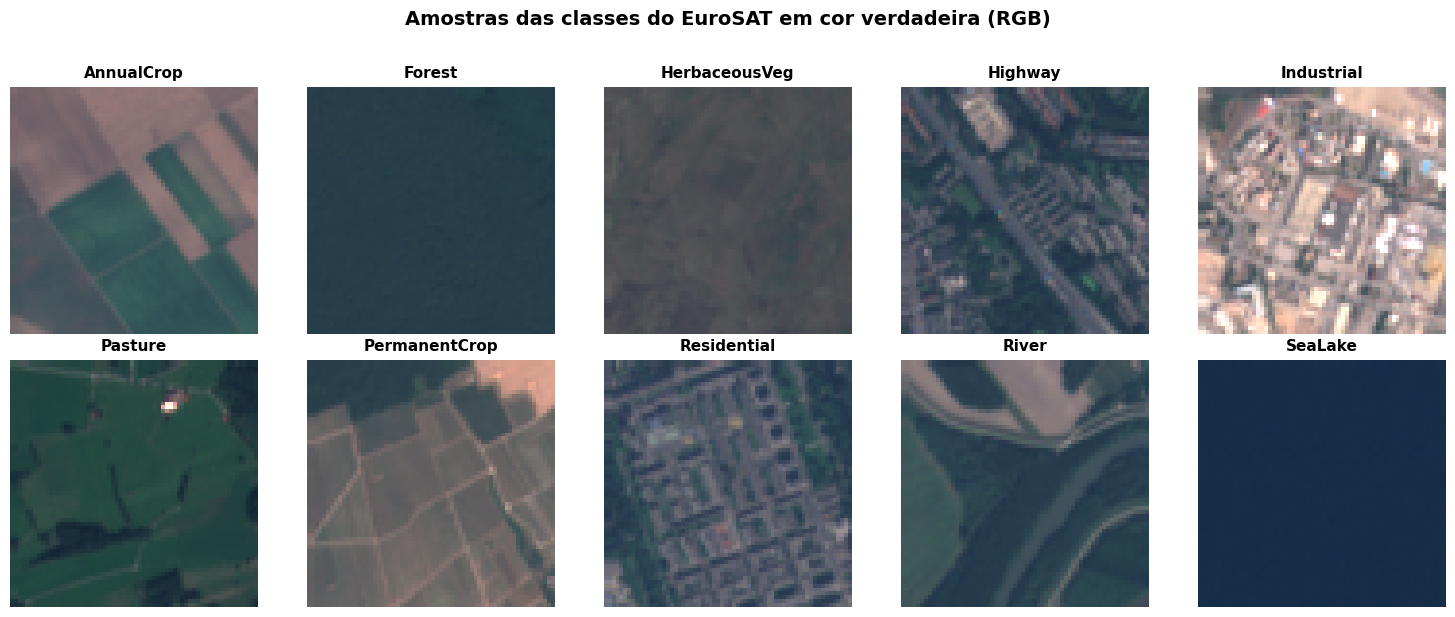

In [13]:
# Exibir uma imagem de exemplo de cada classe a partir do subconjunto de treinamento
amostras_por_classe = {}
for item in train_sub:
    img = item['image']
    lbl = int(item['label'])
    if lbl not in amostras_por_classe:
        amostras_por_classe[lbl] = img.numpy()
    if len(amostras_por_classe) == 10:
        break

# Grade de 2 linhas x 5 colunas (10 amostras)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for c in range(10):
    img_tensor = amostras_por_classe[c] # [B02, B03, B04, B08]
    # Composição Cor Verdadeira: B04 (Red), B03 (Green), B02 (Blue)
    rgb = img_tensor[[2, 1, 0], :, :].transpose(1, 2, 0)
    rgb = np.clip(rgb / 3000.0, 0, 1)

    ax = axes[c]
    ax.imshow(rgb)
    ax.set_title(nomes_classes[c], fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Amostras das classes do EuroSAT em cor verdadeira (RGB)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### **Tradução dos nomes das classes**

| Classe        | Tradução em português |
|:--------------|:----------------------|
| AnnualCrop    | Cultivo anual         |
| Forest        | Floresta              |
| HerbaceousVeg | Vegetação herbácea   |
| Highway       | Rodovia               |
| Industrial    | Industrial             |
| Pasture       | Pastagem              |
| PermanentCrop | Cultivo permanente    |
| Residential   | Área residencial      |
| River         | Rio                   |
| SeaLake       | Mar/Lago              |

---
## **2. Extração das *features* (aquilo que vai ser usado como *input* no classificador): pixels brutos (abordagens 1 e 2) vs. *embeddings* (abordagem 3)**

Para cada amostra/imagem do conjunto de treino e validação, coletaremos:
* ***Features* espectrais:** média da reflectância de cada banda, formando um vetor de 3 dimensões (RGB) ou 4 dimensões (RGB + NIR);
* ***Features* de *embeddings*:** vetor contextual gerado pelo DOFA (vetor de 45 dimensões).

In [14]:
def extrair_features_e_embeddings(model, dataloader, device):
    lista_rgb, lista_rgb_nir, lista_embeddings, lista_rotulos = [], [], [], [] # Abordagem 1, Abordagem 2, Abordagem 3, Rótulos
    wavelengths = torch.tensor([490.0, 560.0, 665.0, 842.0], dtype=torch.float32, device=device) # O DOFA requer os comprimentos de onda centrais das bandas escolhidas

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extraindo"):
            imagens = batch['image'].to(device, non_blocking=True)
            rotulos = batch['label'].numpy()

            # 1. Baseline RGB + NIR (média espacial das 4 bandas) -> cada banda vira um único valor
            rgb_nir_mean = imagens.mean(dim=(-2, -1)).cpu().numpy()

            # 2. Baseline RGB (média espacial das 3 bandas visíveis)  -> cada banda vira um único valor
            rgb_mean = imagens[:, :3, :, :].mean(dim=(-2, -1)).cpu().numpy()

            # 3. DOFA Embeddings
            imagens_resized = F.interpolate(imagens, size=(224, 224), mode='bilinear', align_corners=False) # Reamostra os inputs para 224 x 224 pixels usando bilinear
            embeddings = model(imagens_resized, wavelengths).cpu().numpy() # Lê as imagens reamostradas e os comprimentos de onda definidos anteriormente

            lista_rgb.append(rgb_mean)
            lista_rgb_nir.append(rgb_nir_mean)
            lista_embeddings.append(embeddings)
            lista_rotulos.append(rotulos)

    X_rgb = np.concatenate(lista_rgb, axis=0)
    X_rgb_nir = np.concatenate(lista_rgb_nir, axis=0)
    X_embeds = np.concatenate(lista_embeddings, axis=0)
    y = np.concatenate(lista_rotulos, axis=0)

    return X_rgb, X_rgb_nir, X_embeds, y # x são os dados de treinamento (três abordagens) e y os rótulos

print("Extraindo o subconjunto de treinamento (80 por classe = 800 amostras)...")
X_train_rgb, X_train_rgb_nir, X_train_emb, y_train = extrair_features_e_embeddings(model, train_dl, device)

print("Extraindo o subconjunto de validação (40 por classe = 400 amostras)...")
X_val_rgb, X_val_rgb_nir, X_val_emb, y_val = extrair_features_e_embeddings(model, val_dl, device)

# Conferência obrigatória
print("\nVerificação das amostras presentes na validação:")
for c in range(10):
    cont = np.sum(y_val == c)
    print(f"  {nomes_classes[c]}: {cont} amostras")

Extraindo o subconjunto de treinamento (80 por classe = 800 amostras)...


Extraindo:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torchgeo/models/dofa.py:338: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wavelist = torch.tensor(wavelengths, device=x.device, dtype=x.dtype)


Extraindo o subconjunto de validação (40 por classe = 400 amostras)...


Extraindo:   0%|          | 0/13 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20b8951260>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c20b8951260>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Verificação das amostras presentes na validação:
  AnnualCrop: 40 amostras
  Forest: 40 amostras
  HerbaceousVeg: 40 amostras
  Highway: 40 amostras
  Industrial: 40 amostras
  Pasture: 40 amostras
  PermanentCrop: 40 amostras
  Residential: 40 amostras
  River: 40 amostras
  SeaLake: 40 amostras


---
## **3. O teste: desempenho das classificação supervisionadas com poucos rótulos (*Few-Shot*)**

Agora realizamos o experimento central: selecionamos de forma aleatória e estratificada pequenos subconjuntos de treinamento ($k = 2, 5, 10, 20$ amostras por classe).

Para minizarmos o viés de sorteio, vamos repetir o processo em **cinco rodadas independentes** para calcularmos a média e o desvio padrão da acurácia global na validação.

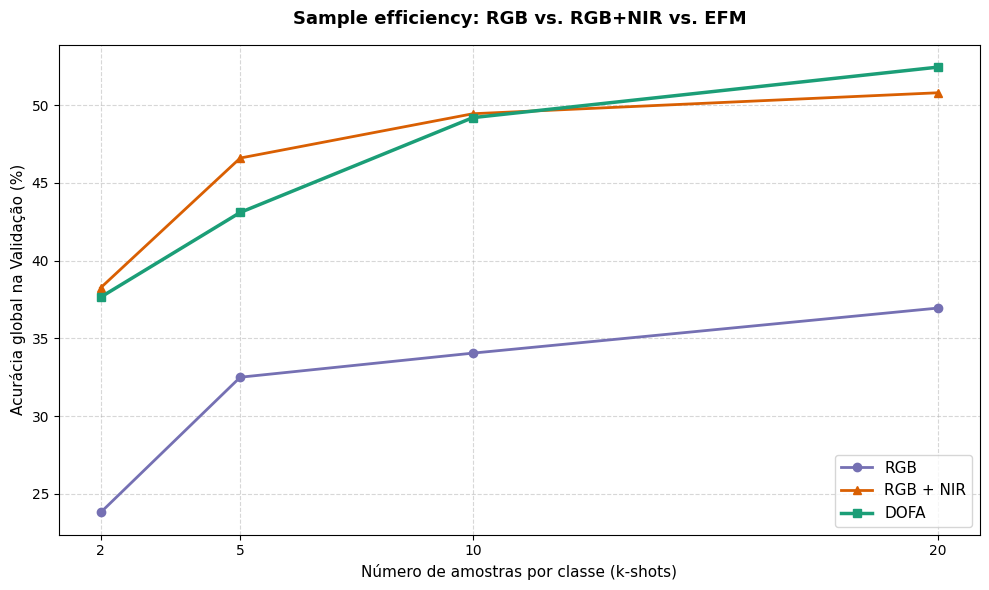

In [15]:
def selecionar_k_shots(X, y, k, seed):
    np.random.seed(seed)
    indices_selecionados = [] # Armazena as amostras sorteadas na rodada
    for c in range(10):
        idx_classe = np.where(y == c)[0]
        amostras_k = np.random.choice(idx_classe, size=k, replace=False)
        indices_selecionados.extend(amostras_k)
    return X[indices_selecionados], y[indices_selecionados]

k_shots = [2, 5, 10, 20] # Define o nosso teste central com poucas amostras
n_seeds = 5 # Repetimos o processo 5 vezes e extraimos a média e o desvio padrão (std)

resultados = {
    'Bandas espectrais (RGB)': {'média': [], 'std': []},
    'Bandas espectrais (RGB + NIR)': {'média': [], 'std': []},
    'Earth Foundation Model (DOFA)': {'média': [], 'std': []}
}

for k in k_shots:
    acc_rgb_seeds, acc_rgb_nir_seeds, acc_emb_seeds = [], [], [] # Listas vazias que armazenarão as acurácias globais

    for seed in range(n_seeds):
        X_sub_rgb, y_sub = selecionar_k_shots(X_train_rgb, y_train, k, seed)
        X_sub_rgb_nir, _ = selecionar_k_shots(X_train_rgb_nir, y_train, k, seed)
        X_sub_emb, _ = selecionar_k_shots(X_train_emb, y_train, k, seed)

        clf_rgb = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed))
        clf_rgb.fit(X_sub_rgb, y_sub)
        acc_rgb_seeds.append(accuracy_score(y_val, clf_rgb.predict(X_val_rgb))) # Treina o classificador (Regressão Logística )com a abordagem 1

        clf_rgb_nir = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed))
        clf_rgb_nir.fit(X_sub_rgb_nir, y_sub)
        acc_rgb_nir_seeds.append(accuracy_score(y_val, clf_rgb_nir.predict(X_val_rgb_nir))) # Treina o classificador (Regressão Logística )com a abordagem 1

        clf_emb = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed))
        clf_emb.fit(X_sub_emb, y_sub)
        acc_emb_seeds.append(accuracy_score(y_val, clf_emb.predict(X_val_emb))) # Treina o classificador (Regressão Logística )com a abordagem 1

    resultados['Bandas espectrais (RGB)']['média'].append(np.mean(acc_rgb_seeds))
    resultados['Bandas espectrais (RGB)']['std'].append(np.std(acc_rgb_seeds))

    resultados['Bandas espectrais (RGB + NIR)']['média'].append(np.mean(acc_rgb_nir_seeds))
    resultados['Bandas espectrais (RGB + NIR)']['std'].append(np.std(acc_rgb_nir_seeds))

    resultados['Earth Foundation Model (DOFA)']['média'].append(np.mean(acc_emb_seeds))
    resultados['Earth Foundation Model (DOFA)']['std'].append(np.std(acc_emb_seeds))

# Curva Global
plt.figure(figsize=(10, 6))
plt.plot(k_shots, np.array(resultados['Bandas espectrais (RGB)']['média']) * 100, marker='o', linewidth=2, label='RGB', color='#7570b3')
plt.plot(k_shots, np.array(resultados['Bandas espectrais (RGB + NIR)']['média']) * 100, marker='^', linewidth=2, label='RGB + NIR', color='#d95f02')
plt.plot(k_shots, np.array(resultados['Earth Foundation Model (DOFA)']['média']) * 100, marker='s', linewidth=2.5, label='DOFA', color='#1b9e77')

plt.title("Sample efficiency: RGB vs. RGB+NIR vs. EFM", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Número de amostras por classe (k-shots)", fontsize=11)
plt.ylabel("Acurácia global na Validação (%)", fontsize=11)
plt.xticks(k_shots)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

No gráfico comparativo das três abordagens (RGB vs. RGB + NIR vs. RGB + NIR + DOFA), vimos que, ao aumentarmos o número de amostras de 2 para 20, o DOFA pode atingir resultados superiores às outras duas abordagens. O *baseline* com as bandas RGB não ultrapassou uma acurácia global de 36% usando 20 amostras, enquanto a agregação da banda do NIR tornou o resultado mais competitivo. Isso se deve à resposta espectral do NIR e à sua boa descrição de diversos alvos de uso e cobertura. Até um k = 10, o uso de RGB + NIR apresentou resultados superiores ao DOFA, mas, com 20 amostras, o resultado se inverteu.

---
## **4. Visualização e comparação dos resultados**

Plotamos as curvas de aprendizado para comparar a evolução da acurácia à medida que aumentamos a disponibilidade de amostras rotuladas.

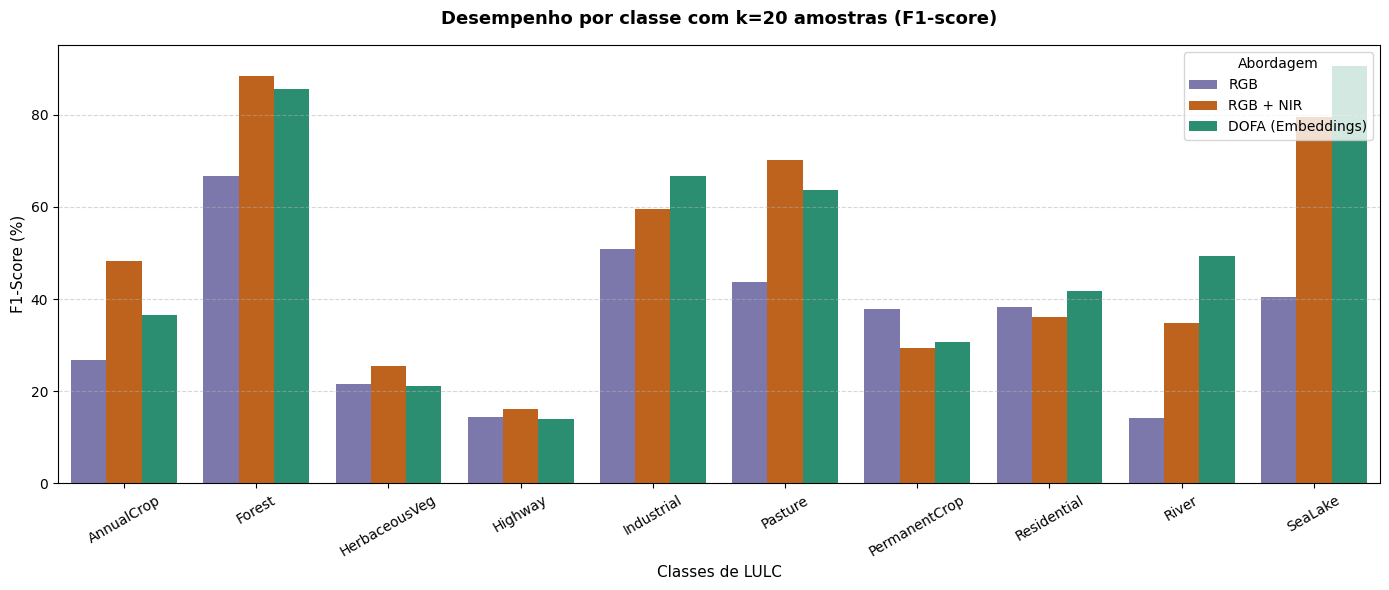

,Classe,RGB,RGB + NIR,DOFA (Embeddings)
0,AnnualCrop,26.9,48.2,36.6
1,Forest,66.7,88.4,85.7
2,HerbaceousVeg,21.5,25.4,21.1
3,Highway,14.5,16.2,14.1
4,Industrial,50.9,59.6,66.7
5,Pasture,43.8,70.1,63.7
6,PermanentCrop,37.8,29.4,30.8
7,Residential,38.2,36.1,41.9
8,River,14.3,34.8,49.4
9,SeaLake,40.5,79.5,90.7


In [16]:
seed_aval = 42
k_aval = 20 # Mude o k se necessário

X_s_rgb, y_s = selecionar_k_shots(X_train_rgb, y_train, k_aval, seed_aval)
X_s_rgb_nir, _ = selecionar_k_shots(X_train_rgb_nir, y_train, k_aval, seed_aval)
X_s_emb, _ = selecionar_k_shots(X_train_emb, y_train, k_aval, seed_aval)

clf_rgb = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed_aval)).fit(X_s_rgb, y_s)
clf_rgb_nir = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed_aval)).fit(X_s_rgb_nir, y_s)
clf_emb = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed_aval)).fit(X_s_emb, y_s)

labels_indices = list(range(10))

rep_rgb = classification_report(y_val, clf_rgb.predict(X_val_rgb), labels=labels_indices, target_names=nomes_classes, output_dict=True, zero_division=0)
rep_rgb_nir = classification_report(y_val, clf_rgb_nir.predict(X_val_rgb_nir), labels=labels_indices, target_names=nomes_classes, output_dict=True, zero_division=0)
rep_emb = classification_report(y_val, clf_emb.predict(X_val_emb), labels=labels_indices, target_names=nomes_classes, output_dict=True, zero_division=0)

df_classes = pd.DataFrame({
    'Classe': nomes_classes,
    'RGB': [rep_rgb[c]['f1-score'] * 100 for c in nomes_classes],
    'RGB + NIR': [rep_rgb_nir[c]['f1-score'] * 100 for c in nomes_classes],
    'DOFA (Embeddings)': [rep_emb[c]['f1-score'] * 100 for c in nomes_classes]
})

df_plot = pd.melt(df_classes, id_vars=['Classe'], var_name='Abordagem', value_name='F1-Score (%)')

plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x='Classe', y='F1-Score (%)', hue='Abordagem', palette=['#7570b3', '#d95f02', '#1b9e77'])
plt.title(f"Desempenho por classe com k={k_aval} amostras (F1-score)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Classes de LULC", fontsize=11)
plt.ylabel("F1-Score (%)", fontsize=11)
plt.xticks(rotation=30)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Abordagem', loc='upper right')
plt.tight_layout()
plt.show()

display(df_classes.round(1))

A análise por classe também evidencia que não há uma vantagem uniforme entre as abordagens. O RGB apresenta limitações mais acentuadas em classes como *River* e *PermanentCrop*, enquanto a inclusão do NIR produz ganhos expressivos em classes como *Forest*, *Pasture* e *SeaLake*. O DOFA, por sua vez, apresenta uma representação mais contextual, com resultados particularmente relevantes em classes como *SeaLake*, *River*, *PermanentCrop* e *Residential*.

**Conclusão**

A disponibilidade de poucas amostras rotuladas é um desafio recorrente na classificação de imagens. Na prática, porém, esse não é apenas um problema técnico: obter imagens e, principalmente, transformá-las em dados rotulados de qualidade exige tempo e muito trabalho. Nos últimos anos, grandes *datasets*, como o ImageNet, foram construídos, mas no sensoriamento remoto a situação é mais complexa. Diferentes sensores, regiões e aplicações podem tornar necessário adaptar esses dados ou utilizá-los com ressalvas. Assim, muitas vezes o usuário ainda precisa construir seu próprio conjunto de dados.

É nesse contexto que os modelos fundacionais de observação da Terra ganham espaço. Por serem treinados previamente com grandes volumes de dados, provenientes de diferentes fontes, eles permitem que parte desse conhecimento seja reaproveitada em novas aplicações, reduzindo a necessidade de começar o treinamento do zero. Isso não significa, entretanto, que os dados do usuário deixem de ser importantes. Pelo contrário: combinar o conhecimento adquirido pelo modelo com um conjunto menor de exemplos rotulados e de boa qualidade pode ser uma forma de aproveitar o melhor dos dois mundos.

Afinal, mais do que simplesmente buscar o melhor resultado em um experimento, o objetivo é tornar possível que uma aplicação de sensoriamento remoto seja desenvolvida mesmo quando os dados disponíveis são extremamente limitados em quantidade.

**Bio**

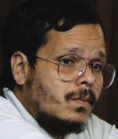

Alisson de Oliveira é Bacharel em Gestão e Análise Ambiental pela Universidade Federal de São Carlos (UFSCar) desde 2021 e Mestre em Sensoriamento Remoto pelo Instituto Nacional de Pesquisas Espaciais (INPE) desde 2024. Atualmente está no terceiro ano do doutorando em Sensoriamento Remoto no INPE, onde desenvolve pesquisas voltadas à análise ambiental utilizando dados de sensoriamento remoto e *machine learning*, como foco na utilização dos satélites brasileiros CBERS-4, CBERS-4A e AMAZONIA-1